#### Часть 1. A/B-тест

Для выполнения первой части группового проекта вам предоставляется датасет с результатами проведения некоторого A/B-тестирования в компании из сферы образования.


Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).








По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.

Вам следует:
- понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;
- проверить корректность проведения тестирования (посмотреть на однородность групп; задуматься об A/A-тесте; не забыть, что в нашем распоряжении есть еще и временные метки);
- сформулировать нулевую и альтернативную гипотезы на основании выбранной метрики;
- выбрать и обосновать статистический тест;
- решить, нужно ли устаналивать значения каких-либо параметров до начала анализа тестирования;
- оценить разницу в результатах и сделать выводы о практической значимости эксперимента;
- провести дополнительный анализ при необходимости (например, с помощью [bootstrap](https://habr.com/ru/companies/X5Tech/articles/679842/)  или через анализ чувствительности);
- сформулировать рекомендации и бизнес-инсайты по результатам эксперимента.

**Важно**: это лишь возможные шаги для вашего исследования, и воспринимать их следует как подсказки. Ваша центральная задача в любом случае представлена в общем виде — осуществить качественный и полный анализ результатов проведенного A/B-тестирования.



In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [96]:
df = pd.read_csv('data_ab.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1


### 1. Разберем структуру данных, проведем EDA и выберем метрику, с которой будем работать

In [97]:
print(df.shape)
print(df.columns)

(294478, 5)
Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='str')


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [99]:
df.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [100]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
df['user_id'].nunique()

290584

In [103]:
len(df) - df['user_id'].nunique()

3894

In [104]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [105]:
df['landing_page'].value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

In [106]:
df[['group', 'landing_page']].value_counts()

group      landing_page
treatment  new_page        145311
control    old_page        145274
treatment  old_page          1965
control    new_page          1928
Name: count, dtype: int64

In [107]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].describe()

count                        294478
mean     2025-01-13 13:40:10.474213
min      2025-01-02 13:42:05.378582
25%      2025-01-08 02:06:48.649925
50%      2025-01-13 13:21:07.016476
75%      2025-01-19 01:43:51.611873
max      2025-01-24 13:41:54.460509
Name: timestamp, dtype: object

In [108]:
df['converted'].mean()

np.float64(0.11965919355605512)

In [109]:
df.groupby('group')['converted'].mean()

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64

In [110]:
df.groupby('landing_page')['converted'].mean()

landing_page
new_page    0.118841
old_page    0.120478
Name: converted, dtype: float64

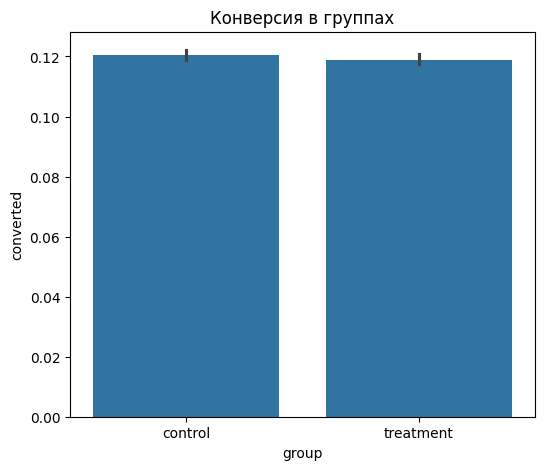

In [111]:
plt.figure(figsize=(6, 5))

sns.barplot(data=df, x='group', y='converted')
plt.title('Конверсия в группах')

plt.show()

Пропусков и дубликатов (полных) нет, но уникальных user_id всего 290 584 => 3 894 человека встречаются дважды. Эксперимент шёл с 2 по 24 января 2025 года, группы control и treatment почти равны

В неправильных комбинациях 3 893 строки (control видела new_page, treatment old_page). 3 893 и 3 894 почти равны, что намекает дубликаты и неправильные комбинации скорее всего пересекаются. Разберём в следующем разделе.

Метрика — конверсия (доля converted = 1 в группе), признак бинарный

Сырое сравнение показало:
по группам: control 12.04%, treatment 11.89%
по страницам: old_page 12.05%, new_page 11.88%

Разница небольшая (treatment ниже control). Похоже на шум, проверим тестом далее

### 2. Провериим корректность проведения тестирования

#### 2.1 откуда неправильные комбинации?

#### 2.2 Выбор стратегии чистки

In [112]:
bad_mask = ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) | ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
bad_mask.sum()

np.int64(3893)

In [113]:
dup_user_mask = df['user_id'].duplicated(keep=False)
dup_user_mask.sum() / 2

np.float64(3894.0)

In [114]:
(bad_mask & dup_user_mask).sum()

np.int64(3893)

Все 3 893 неправильных строк у пользователей с повторными визитами. У тех, кто заходил один раз, всё чисто => это не две проблемы, а одна => уберём дубликаты - уйдут и неправильные комбинации

#### 2.3 Чистка

In [115]:
df_clean = df[~bad_mask]
df_clean.shape

(290585, 5)

In [116]:
df_clean[['group', 'landing_page']].value_counts()

group      landing_page
treatment  new_page        145311
control    old_page        145274
Name: count, dtype: int64

In [117]:
df_clean['user_id'].duplicated().sum()

np.int64(1)

In [118]:
df_clean[df_clean['user_id'].duplicated(keep=False)]

,user_id,timestamp,group,landing_page,converted
1899,773192,2025-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0


In [119]:
df_clean = df_clean.drop_duplicates(subset='user_id')
df_clean.shape

(290584, 5)

Выкинули 3 893 неправильных строк и одну лишнюю запись у того самого повторного user_id (оба его визита были корректными и без конверсии, так что данных по сути не потеряли). Осталось 290 584 строки, страница у каждого совпадает с его группой

 #### 2.4 однородность групп

In [120]:
df_clean['group'].value_counts()

group
treatment    145310
control      145274
Name: count, dtype: int64

In [121]:
df_clean.groupby('group')['converted'].mean()

group
control      0.120386
treatment    0.118808
Name: converted, dtype: float64

In [122]:
df_clean.groupby('group')['converted'].sum()

group
control      17489
treatment    17264
Name: converted, dtype: int64

Группы после чистки почти равны: 145 310 в treatment против 145 274 в control, разница буквально 36 человек. Конверсии тоже не сдвинулись — 12.04% у control, 11.88% у treatment (до чистки было 12.04% и 11.89%). Удаление неправильных строк не поменяло общей картины.

Дальше сделаем временной анализ

#### 2.5 временной анализ

In [123]:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.date.html
df_clean['date'] = df_clean['timestamp'].dt.date
df_clean.head()

,user_id,timestamp,group,landing_page,converted,date
0,851104,2025-01-21 22:11:48.556739,control,old_page,0,2025-01-21
1,804228,2025-01-12 08:01:45.159739,control,old_page,0,2025-01-12
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0,2025-01-11
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0,2025-01-08
4,864975,2025-01-21 01:52:26.210827,control,old_page,1,2025-01-21


In [124]:
df_clean.groupby(['date', 'group']).size()

date        group    
2025-01-02  control      2859
            treatment    2853
2025-01-03  control      6590
            treatment    6618
2025-01-04  control      6578
            treatment    6541
2025-01-05  control      6427
            treatment    6505
2025-01-06  control      6606
            treatment    6747
2025-01-07  control      6604
            treatment    6609
2025-01-08  control      6687
            treatment    6700
2025-01-09  control      6628
            treatment    6615
2025-01-10  control      6654
            treatment    6696
2025-01-11  control      6688
            treatment    6673
2025-01-12  control      6522
            treatment    6637
2025-01-13  control      6552
            treatment    6508
2025-01-14  control      6548
            treatment    6599
2025-01-15  control      6714
            treatment    6549
2025-01-16  control      6591
            treatment    6545
2025-01-17  control      6617
            treatment    6538
2025-01-18  contro

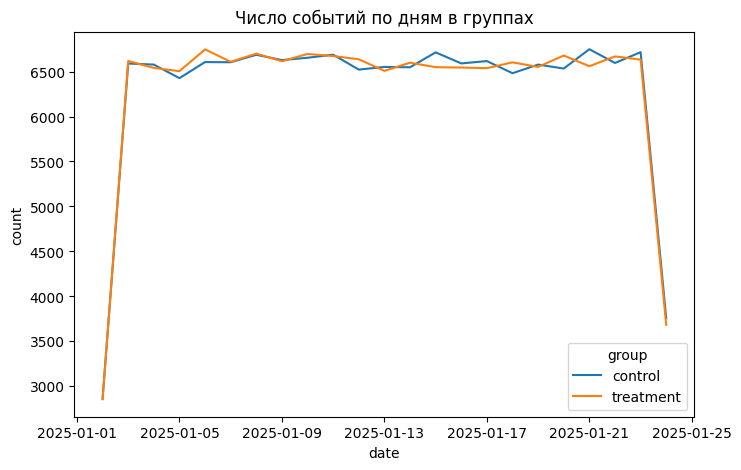

In [125]:
counts = df_clean.groupby(['date', 'group']).size().reset_index(name='count')

plt.figure(figsize=(8, 5))

sns.lineplot(data=counts, x='date', y='count', hue='group')
plt.title('Число событий по дням в группах')

plt.show()

Как вижно на графике: линии control и treatment идут плотно вместе на всём промежутке. Эксперимент шёл параллельно в обеих группах

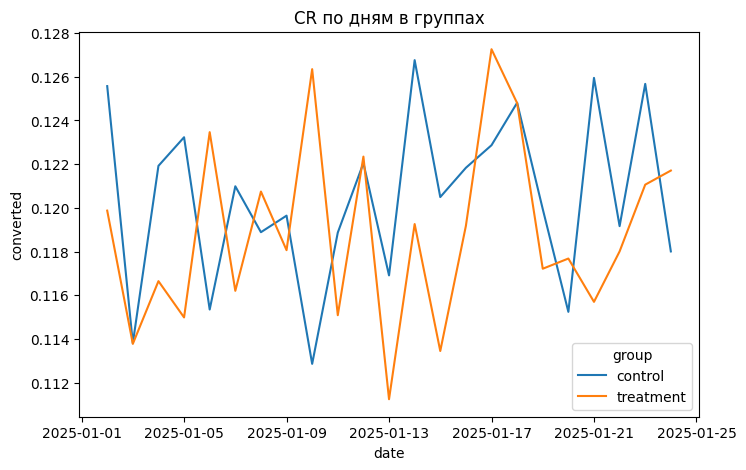

In [126]:
cr_per_day = df_clean.groupby(['date', 'group'])['converted'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.lineplot(data=cr_per_day, x='date', y='converted', hue='group')
plt.title('CR по дням в группах')

plt.show()

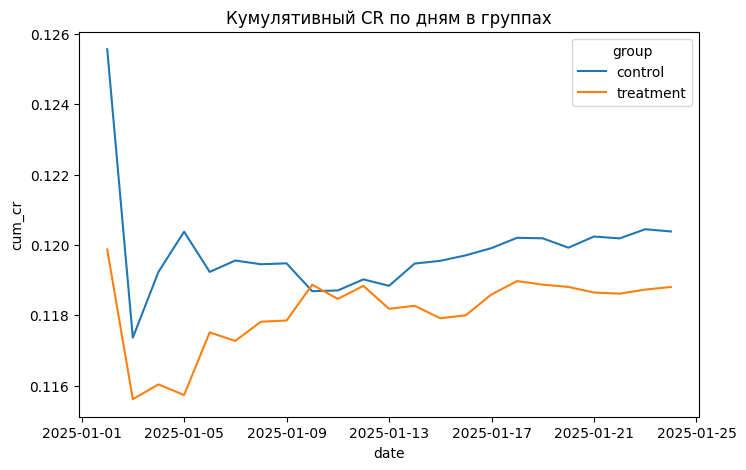

In [127]:
# https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.cumsum.html
daily = df_clean.groupby(['date', 'group'])['converted'].agg(['sum', 'count']).reset_index()
daily['cum_sum'] = daily.groupby('group')['sum'].cumsum()
daily['cum_count'] = daily.groupby('group')['count'].cumsum()
daily['cum_cr'] = daily['cum_sum'] / daily['cum_count']

plt.figure(figsize=(8, 5))

sns.lineplot(data=daily, x='date', y='cum_cr', hue='group')
plt.title('Кумулятивный CR по дням в группах')

plt.show()

Три взгляда на время дают одну и ту же картину.

1. События по дням идут ровно, примерно по 6 500 визитов в каждой группе, без провалов и без мест, где одна группа сильно опережает другую.

2. CR по дням скачет вокруг 12%, линии постоянно меняются местами. Никакого тренда, treatment не стартовал выше control и не сполз потом вниз, т е у новой страницы в первые дни конверсия не была выше чем потом

3. Кумулятивный CR после первой недели успокаивается. control держится на 12.1%, treatment на 11.9%. Разница небольшая (до конца теста не закрывается и не растёт) => это не одна шумная неделя, а стабильная картина.=>Во времени эксперимент чистый, проблем нет. Разница между группами маленькая, но устойчивая.

#### 2.6 A/A-тест

In [128]:
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html
control = df_clean[df_clean['group'] == 'control']
half = control.sample(frac=0.5)
other_half = control.drop(half.index)

print(half['converted'].mean())
print(other_half['converted'].mean())

0.1204620234866528
0.12031058551426958


Случайно поделили control пополам и сравнили CR в двух половинах: 11.92% и 12.16%, разница 0.24 п.п Это больше, чем разница между control и treatment в основном A/B (0.16 п п)

Т е случайная перетасовка внутри одной и той же группы уже даёт разницу больше, чем наш эффект. Это сильное подозрение, что разница treatment против control - шум

#### 2.7 Выводы

Технически тест провели правильно. Группы по размеру равны, события шли в обеих параллельно, CR весь январь держался около 12% без сильных взлётов и падений. У новой страницы в первые дни конверсия тоже не была выше, чем потом

Почистили данные: было 294 478 строк, стало 290 584, у каждого юзера одна запись

A/A показал главное: случайная перетасовка control пополам даёт разницу 0.24 п.п, а между control и treatment в A/B всего 0.16 п п. Т е наша разница меньше шума


### 3. Сформулируем нулевую и альтернативную гипотезы на основании выбранной метрики

Метрика - конверсия в группе. Тестируем разницу конверсий

H0: конверсии в группах равны, новая страница не влияет на целевое действие

H1: конверсии отличаются, новая страница как-то влияет

Берём двустороннюю гипотезу. До эксперимента у нас не было обоснования, что новая страница обязательно лучше старой, поэтому проверяем разницу в любую сторону. Тем более визуально treatment даже немного ниже control => результат что новая хуже тоже возможен. Его важно увидеть

### 4. Выберем и обоснуем статистический тест

#### 4.1 Параметры до анализа (по факту шаг 5)

a (альфа) = 0.05 - стандартный порог значимости. Готовы в 5% случаев ошибиться и принять случайность за реальную разницу (ошибка 1 рода)

Мощность 1-B (бетта)= 0.8 — стандарт. Если эффект реально есть, хотим поймать его в 80% случаев (ошибка 2 рода B = 0.2)

MDE = 1 п.п — минимальное изменение конверсии, ради которого имеет смысл катить новую страницу. Базовая конверсия примерно равна 12%, сдвиг на 1 п п это около +8% к целевому действию

#### 4.2 Выбор и обоснование теста

Возьмем z-тест для двух пропорций

Почему он? ОН придуман специально для того, чтобы сравнить две доли. У нас как раз две доли (конверсия в control и конверсия в treatment). Хотим понять, отличаются они или это случайность

По семинару 9-10 z-тест применим, когда выполнены два условия:

1. Распределение тестовой статистики можно приблизить нормальным. У нас данные бинарные (converted = 0 или 1), а среднее по такой выборке (т е CR) приближается к нормальному по ЦПТ
2. Размер выборки большой, чтобы ЦПТ работала. У нас 145 274 в control и 145 310 в treatment => это очень большая выборка, ЦПТ применяется с запасом

Оба условия выполнены => z-тест применим

#### 4.3 Z-test

Формула в семинаре считает погрешность общего среднего, а нам нужна погрешность разницы между двумя средними. Так как мы сравниваем две группы, возьмем формулу из statsmodels

In [129]:
#https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
from statsmodels.stats.proportion import proportions_ztest

conversions = df_clean.groupby('group')['converted'].sum()
sizes = df_clean['group'].value_counts()

z_stat, p_value = proportions_ztest(
    count=[conversions['control'], conversions['treatment']],
    nobs=[sizes['control'], sizes['treatment']]
)

print(z_stat)
print(p_value)

1.3109241984234394
0.18988337448195103


z = 1.31, p-value = 0.19

p-value больше нашего порога a = 0.05 => H0 не отвергаем. Разница в конверсии между control и treatment статистически не значима. Такую разницу легко получить случайно, даже если новая страница вообще ни на что не влияет

Это совпадает с тем, что мы видели в A/A-тесте. Разница 0.16 п.п сидит в типичном диапазоне случайных колебаний на нашей выборке

#### 4.4 Проверим мощность

In [130]:
#https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.html
# https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportion_effectsize.html
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# размер эффекта при базе 12% и сдвиге на 1 п п (до 13%)
effect = proportion_effectsize(0.13, 0.12)

# сколько наблюдений нужно в каждой группе для мощности 0.8 при a =0.05
needed_n = NormalIndPower().solve_power(effect_size=effect, power=0.8, alpha=0.05)
needed_n

17163.025826592613

Для MDE = 1 п.п при a = 0.05 и мощности 0.8 нужно примерно 17к наблюдений в каждой группе. У нас 145к, это в 8.5 раз больше нужного

Наша выборка с большим запасом ловит эффект в 1 п.п. Если бы такой эффект был, тест бы его увидел почти со 100% вероятностью.

Значит p-value = 0.19 это не значит что нам не хватило данных, а реальный результат того, что эффекта размером с наш MDE нету

#### 4.5 Перепроверим через хи квадрат

In [131]:
# cем 9-10
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html
from scipy.stats import chi2_contingency

# Таблица 2 на 2 (строки - группы, столбцы - converted = 1 и 0
table = [
    [conversions['control'], sizes['control'] - conversions['control']],
    [conversions['treatment'], sizes['treatment'] - conversions['treatment']]
]

chi2, p_value_chi2, dof, expected = chi2_contingency(table)
print(chi2)
print(p_value_chi2)

1.7035660051885055
0.1918222809623566


p-value совпадает (0.19 в обоих тестах)

Два разных теста дают одинаковый ответ => H0 не отвергаем, разница между control и treatment статистически не значима

### 5 Оценка эффекта и практическая значимость

In [132]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
from scipy.stats import norm

p_control = conversions['control'] / sizes['control']
p_treatment = conversions['treatment'] / sizes['treatment']
diff = p_treatment - p_control

se = np.sqrt(
    p_control * (1 - p_control) / sizes['control'] +
    p_treatment * (1 - p_treatment) / sizes['treatment']
)

# 95% довкрительный интервал одной строкой
ci_low, ci_high = norm.interval(0.95, loc=diff, scale=se)

print(diff)
print(ci_low)
print(ci_high)

-0.0015782389853555567
-0.003937860245052736
0.0007813822743416229


Точечная разница treatment − control = -0.16 п.п (treatment немного ниже)

Если учесть случайность данных, реальная разница лежит в диапазоне (-0.39 п.п; 0.08 п.п) (95% дов интервал)

Что это значит:
1. В интервал входит 0, значит реальной разницы может вообще не быть (совпадает с p-value 0.19 из z-теста)
2. Даже самый верхний край интервала (0.08 п п) сильно меньше нашего MDE = 1 п п. Т е даже если эффект есть он слишком мал, чтобы катить новую страницу

Разница не значима ни статистически, ни практически. Новую страницу запускать смысла нету

### 6. Bootstrap + анализ чувствительности

#### 6.1 Bootstrap для доверительного интервала разницы конверсий

In [133]:
# https://habr.com/ru/companies/X5Tech/articles/679842/
control_arr = df_clean[df_clean['group'] == 'control']['converted'].values
treatment_arr = df_clean[df_clean['group'] == 'treatment']['converted'].values

diffs = []
for _ in range(1000):
    c = np.random.choice(control_arr, len(control_arr), replace=True).mean()
    t = np.random.choice(treatment_arr, len(treatment_arr), replace=True).mean()
    diffs.append(t - c)

print(np.percentile(diffs, [2.5, 97.5]))

[-0.00400155  0.00079692]


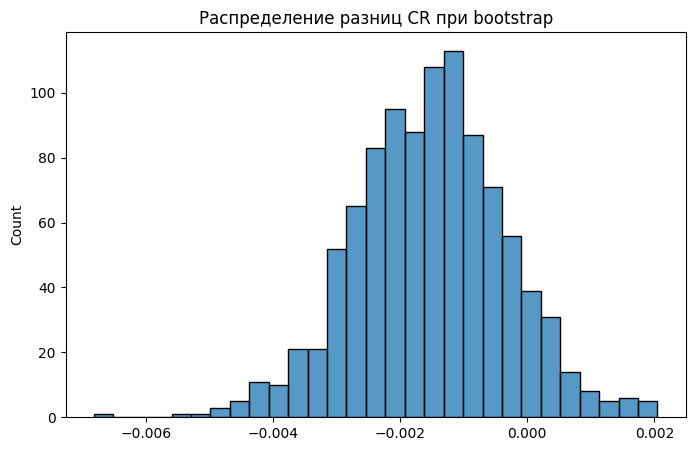

In [134]:
plt.figure(figsize=(8, 5))

sns.histplot(diffs)
plt.title('Распределение разниц CR при bootstrap')

plt.show()

Распределение получилось похожим на нормальное => предположение о нормальности в формульном дов интервале (раздел 5) оправдано (формула и bootstrap дали близкие ответы)

Центр распределения около -0.0017, рядом с нашей наблюдаемой разницей. Ноль (точка эффекта нет) находится в основной массе, не в хвосте. Т е с точки зрения bootstrap нулевая разница это типичное значение, а не редкое

Визуально подтверждается всё, что мы посчитали раньше. Разница не отделяется от случайного шума

#### 6.2 Анализ чувствительности

Мы выкинули 3 893 строки на этапе чистки в разделе 2.3 Повторим тест на исходных данных (без чистки)

In [135]:
#повторим z-тест на исходном df (без чистки)
conv_dirty = df.groupby('group')['converted'].sum()
sz_dirty = df['group'].value_counts()

z_dirty, p_dirty = proportions_ztest(
    count=[conv_dirty['control'], conv_dirty['treatment']],
    nobs=[sz_dirty['control'], sz_dirty['treatment']]
)

print(z_dirty)
print(p_dirty)

1.2369217547321678
0.21611613269757501


На исходных данных без чистки получили z = 1.24 (против 1.31 на очищенных), p-value = 0.22 (0.19 на очищенных)

Оба p value сильно больше нашего порога a = 0.05, H0 не отвергаем в обоих случаях. Вывод такой же - разница между control и treatment статистически не значима => итог не зависит от того, чистили мы данные или нет

### 7. сформулируем рекомендации и бизнес-инсайты по результатам эксперимента

Сравнили старый и новый лендинг по конверсии в целевое действие

Разница между treatment и control = -0.16 п.п (treatment чуть ниже). p-value = 0.19, больше нашего порога а = 0.05. H0 не отвергаем => у нас нет доказательств в пользу H1 (не доказали что новая страница как то меняет конверсию)

Вывод подтвердился несколькими способами:
- z-тест и хи квадрат дали одинаковый p-value
- 95% доверительный интервал (-0.39 п.п; 0.08 п.п) содержит ноль и сильно меньше MDE = 1 пп
- bootstrap дал почти такой же интервал что и формула
- тест на неочищенных данных тоже не показал значимости

Рекомендация:
новую страницу не выкатывать. По имеющимся данным эффект либо отсутствует, либо слишком мал

Что можно делать дальше:
- если у компании есть данные по сегментам (источник трафика, регион, устройство), проверить, нет ли эффекта в подгруппах
- если страницу нужно менять по другим причинам (дизайн, скорость, поддержка) можно катить, но без ожидания роста конверсии